# Tarea 3
Pedro Dañobeytia Gomez

202243913-1

Todos los análisis estadísticos se tomarán en cuenta usando 95% de confianza.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer
import semopy
import missingno as msno
import time
import re
import nltk
from nltk.corpus import stopwords
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.base import clone

import warnings
warnings.filterwarnings('ignore')

### 1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [24]:
data = pd.read_csv('LAB-MAAPD-main/data/junaeb2n.csv')

# Tipos y % NaN

Tabla = pd.DataFrame({ 'Tipo' : data.dtypes, '% NaN' : (data.isna().mean()* 100).round(2)}).sort_values('% NaN', ascending = False)

print(Tabla.to_string())

               Tipo  % NaN
act_fisica  float64   3.43
educm       float64   1.32
sexo          int64   0.00
edad          int64   0.00
vive_madre    int64   0.00
sk1           int64   0.00
imce        float64   0.00
vive_padre    int64   0.00
sk3           int64   0.00
sk2           int64   0.00
sk4           int64   0.00
sk5           int64   0.00
sk8           int64   0.00
sk9           int64   0.00
sk6           int64   0.00
sk7           int64   0.00
sk11          int64   0.00
sk10          int64   0.00
sk13          int64   0.00
sk12          int64   0.00
area          int64   0.00
educp         int64   0.00
madre_work    int64   0.00
resumen_sk   object   0.00


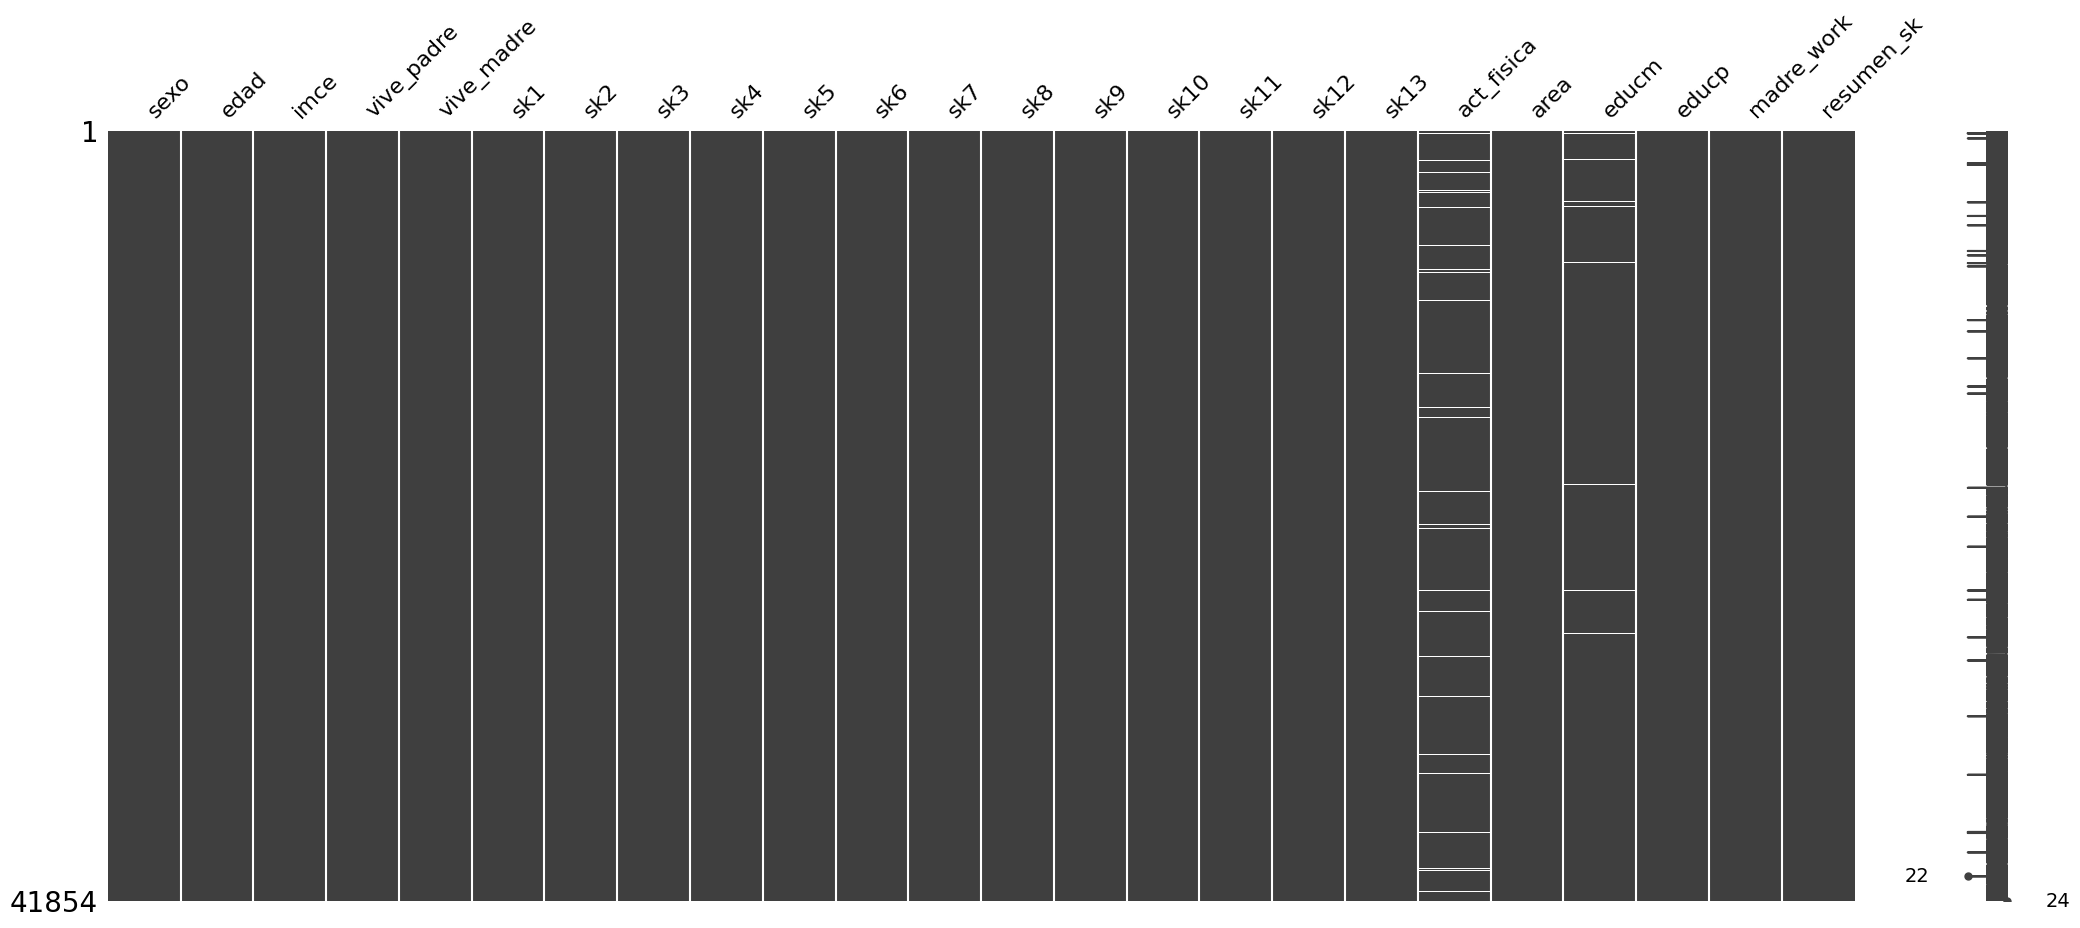

In [25]:
msno.matrix(data)
plt.show()

In [26]:
display(data.head(5))

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,resumen_sk
0,1,85,0.75,1,1,1,1,1,2,1,...,2,2,3,2,NaN,0,11.0,11,-1,"En el plano afectivo y emocional, la dimension..."
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,5.0,0,8.0,8,1,"En el plano afectivo y emocional, la dimension..."
2,1,68,0.27,0,1,2,2,3,2,1,...,3,2,1,3,NaN,1,13.0,13,1,"En el plano afectivo y emocional, la dimension..."
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,2.0,1,16.0,12,-1,"En el plano afectivo y emocional, la dimension..."
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1.0,1,17.0,15,0,"En el plano afectivo y emocional, la dimension..."


In [27]:
data.dropna(subset = ['act_fisica', 'educm'], inplace = True)

pos_vars = ['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk8',
 'sk9', 'sk10', 'sk11', 'sk12', 'sk13']

for col in pos_vars:
    data[col] = 6 - data[col]

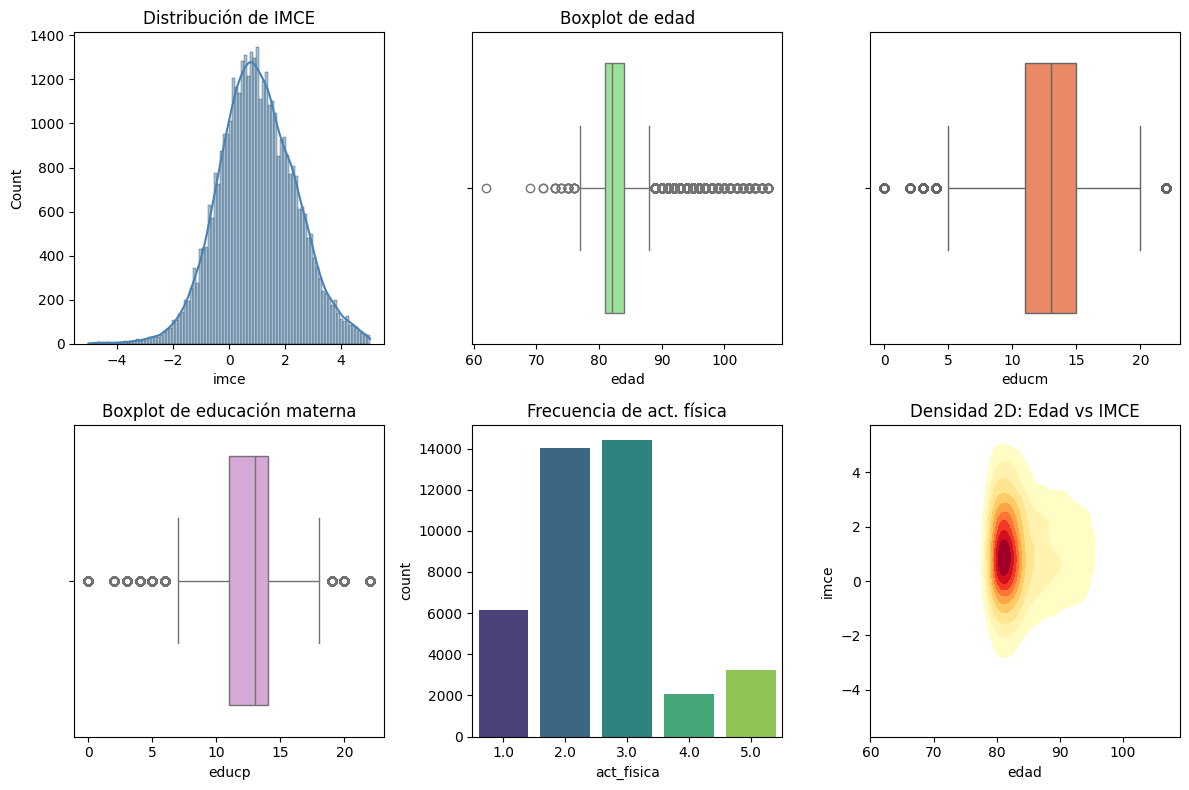

In [28]:
fig, axes = plt.subplots(2, 3, figsize = (12, 8))

# Distribución de IMCE
sns.histplot(data['imce'], kde = True, ax = axes[0, 0], color = 'steelblue')
axes[0, 0].set_title('Distribución de IMCE')

# Boxplot de edad
sns.boxplot(x = data['edad'], ax = axes[0, 1], color = 'lightgreen')
axes[0, 1].set_title('Boxplot de edad')

# Boxplot de educación materna
sns.boxplot(x = data['educm'], ax = axes[0, 2], color = 'coral')
axes[1, 0].set_title('Boxplot de educación materna')

# Boxplot de educación paterna
sns.boxplot(x = data['educp'], ax = axes[1, 0], color = 'plum')
axes[1, 1].set_title('Boxplot de educación paterna')

# Distribución de actividad física con paleta viridis
sns.countplot(x = data['act_fisica'], ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Frecuencia de act. física')

# Densidad 2D de edad vs IMCE
sns.kdeplot(x = data['edad'], y = data['imce'], fill = True, cmap = 'YlOrRd', ax = axes[1, 2], thresh = 0.05)
axes[1, 2].set_title('Densidad 2D: Edad vs IMCE')

plt.tight_layout()
plt.show()

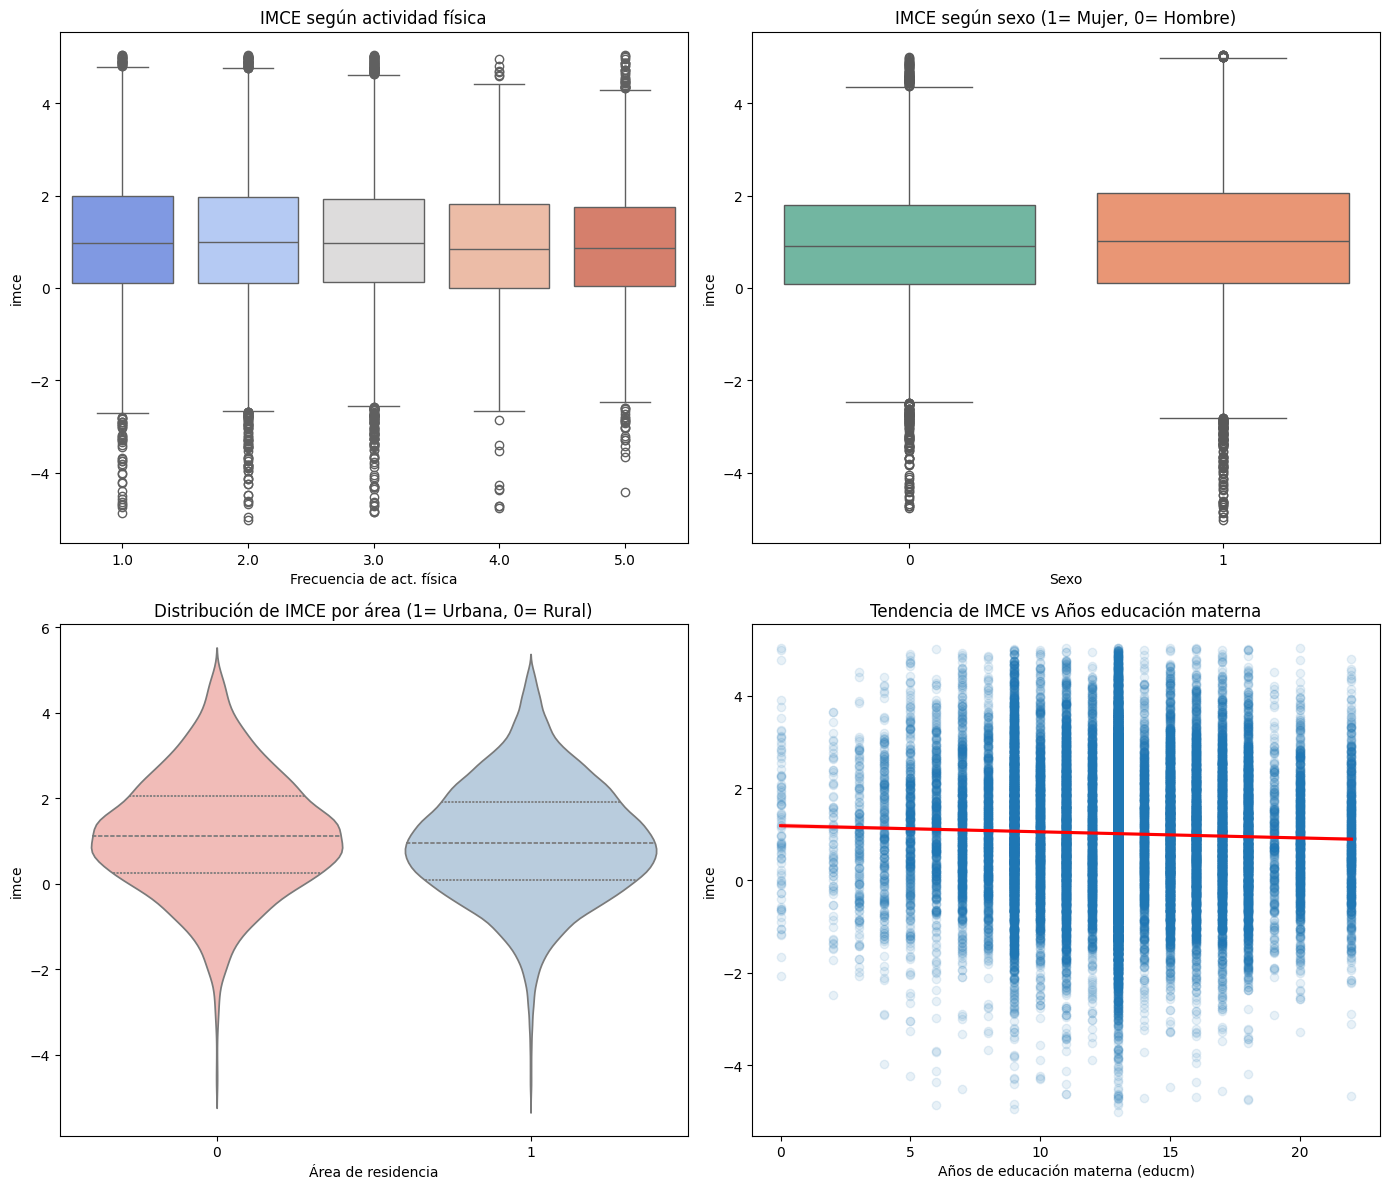

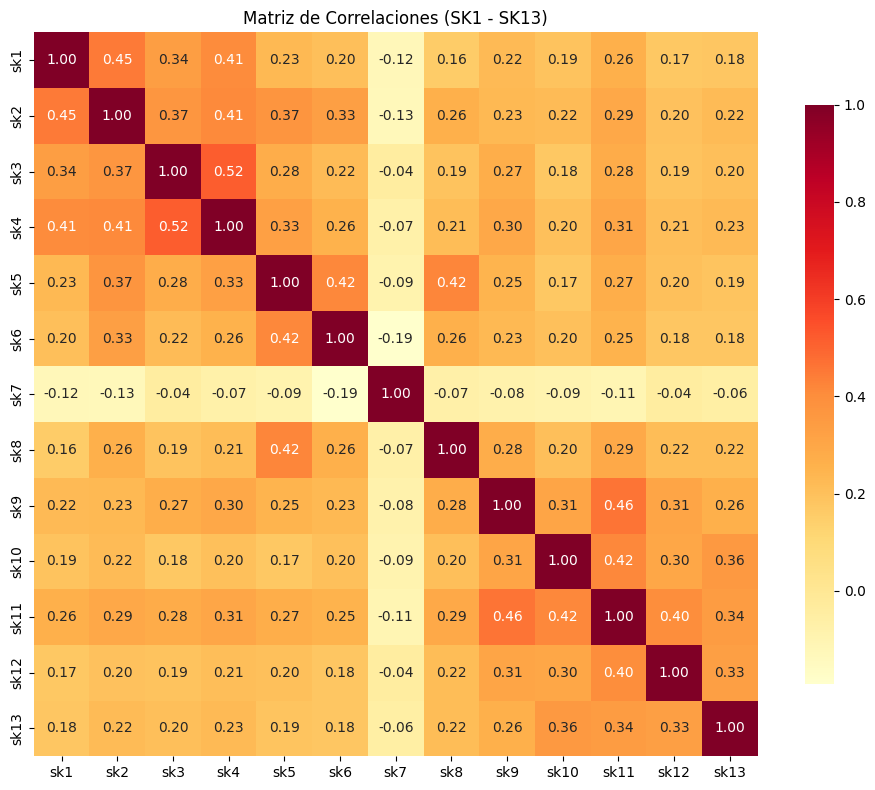

In [29]:
fig, axes = plt.subplots(2, 2, figsize = (14, 12))

# Boxplot de IMCE por actividad física
sns.boxplot(x = 'act_fisica', y = 'imce', data = data, ax = axes[0, 0], palette = 'coolwarm')
axes[0, 0].set_title('IMCE según actividad física')
axes[0, 0].set_xlabel('Frecuencia de act. física')

# Boxplot de IMCE por sexo
sns.boxplot(x = 'sexo', y = 'imce', data = data, ax = axes[0, 1], palette = 'Set2')
axes[0, 1].set_title('IMCE según sexo (1= Mujer, 0= Hombre)')
axes[0, 1].set_xlabel('Sexo')

# Violinplot de IMCE por área (urbano/rural)
sns.violinplot(x = 'area', y = 'imce', data = data, ax = axes[1, 0], palette = 'Pastel1', inner = "quartile")
axes[1, 0].set_title('Distribución de IMCE por área (1= Urbana, 0= Rural)')
axes[1, 0].set_xlabel('Área de residencia')

# Dispersión (regplot) de IMCE vs Educación materna
sns.regplot(x = 'educm', y = 'imce', data = data, ax = axes[1, 1], scatter_kws = {'alpha': 0.1}, line_kws = {'color': 'red'})
axes[1, 1].set_title('Tendencia de IMCE vs Años educación materna')
axes[1, 1].set_xlabel('Años de educación materna (educm)')
plt.tight_layout()
plt.show()

# Matriz de correlación de habilidades socioemocionales (sk1-sk13)
plt.figure(figsize=(10, 8))
corr_matrix = data[['sk' + str(i) for i in range(1, 14)]].corr()
sns.heatmap(corr_matrix, cmap = 'YlOrRd', annot = True, fmt = '.2f', square = True, cbar_kws = {"shrink": .8})
plt.title('Matriz de Correlaciones (SK1 - SK13)')
plt.tight_layout()
plt.show()

Se carga el dataset `junaeb2n.csv` que contiene información psicosocial, demográfica y física de estudiantes chilenos evaluados por JUNAEB, con **41,854 observaciones** y **24 variables**, se hizo una breve exploración de datos y se hizo lo siguiente.

**Limpieza de datos:** Las variables `act_fisica` y `educm` presentaban un **3.43%** y **1.32%** de valores faltantes respectivamente. Dado que representan variables relevantes para el análisis y su proporción de NaN es baja, se optó por eliminar las filas con valores faltantes en dichas columnas, resultando en un dataset final de **40,381 observaciones**. El resto de las variables no presentó valores faltantes. Las variables `sk1`-`sk13`, a excepción de `sk7`, fueron recodificadas mediante la transformación `6 - x` para invertir la escala y asegurar que todas representen aspectos positivos del desarrollo del niño, de modo que una mayor puntuación refleje siempre un mejor indicador. La variable `sk7` ("es agresivo") no fue recodificada dado que su sentido original ya implica una connotación negativa que será analizada en la Pregunta 2.

**Estadísticas descriptivas:** El **IMCE** presenta una distribución aproximadamente normal con media cercana a 0, con colas asimétricas que sugieren la presencia de estudiantes con índices de masa corporal extremos. La **edad** (en meses) muestra valores atípicos en el boxplot, pero son biológicamente plausibles dentro del rango escolar. La **educación materna y paterna** exhiben distribuciones similares, con mediana en torno a los 12 años de escolaridad, lo que indica que la mayoría de los padres completó la enseñanza media. La **actividad física** muestra una distribución concentrada en los valores extremos (1 y 5), revelando una polarización en los hábitos de ejercicio de los estudiantes: una fracción importante es muy activa y otra es completamente sedentaria. El análisis bivariado confirma que el IMCE no varía significativamente según el área geográfica ni el sexo del estudiante, pero sí muestra una leve tendencia negativa con la educación materna, lo que podría sugerir que familias con mayor escolaridad tienen mayor control sobre el peso de sus hijos.

### 2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

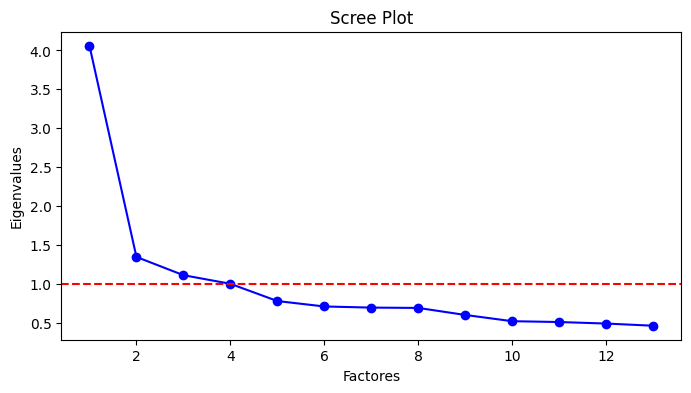

Número de factores con eigenvalue > 1: 4


In [65]:
# Se sleccionan las variables
data_sk = data[['sk' + str(i) for i in range(1, 14)]]

# EFA para determinar eigenvalues
fa_temp = FactorAnalyzer(rotation = None).fit(data_sk)
eigenvalues, _ = fa_temp.get_eigenvalues()

# Gráfico
plt.figure(figsize=(8,4))
plt.plot(range(1, 14), eigenvalues, 'o-', color='blue')
plt.title('Scree Plot')
plt.xlabel('Factores')
plt.ylabel('Eigenvalues')
plt.axhline(y=1, color='r', linestyle='--')
plt.show()

n_factors = sum(eigenvalues > 1)
print(f"Número de factores con eigenvalue > 1: {n_factors}")

In [32]:
fa = FactorAnalyzer(n_factors=3, rotation='varimax').fit(data_sk)
loadings = pd.DataFrame(fa.loadings_, index = data_sk.columns, columns = [f'Factor{i+1}' for i in range(3)])

def highlight_loadings(val):
    if abs(val) > 0.4:
        return 'background-color: lightblue; color: black'
    return ''

display(loadings.style.map(highlight_loadings))

print("\nComunalidades:")
print(fa.get_communalities())

print("\nVarianza de los factores:")
print(fa.get_factor_variance())

print("\nModelo CFA sugerido por semopy:")

,Factor1,Factor2,Factor3
sk1,0.168627,0.546201,0.150317
sk2,0.169615,0.521612,0.350736
sk3,0.186998,0.589452,0.158949
sk4,0.194442,0.673242,0.193061
sk5,0.117685,0.213396,0.729676
sk6,0.173521,0.206983,0.484532
sk7,-0.072735,-0.079992,-0.144848
sk8,0.264605,0.101318,0.473972
sk9,0.497989,0.214232,0.204119
sk10,0.553557,0.120413,0.129000



Comunalidades:
[0.34936557 0.42386385 0.40768648 0.52833461 0.59181513 0.30772287
 0.03266988 0.30493068 0.33555271 0.33756563 0.52319356 0.30937374
 0.28584918]

Varianza de los factores:
(array([1.76205037, 1.61756313, 1.35831039]), array([0.13554234, 0.12442793, 0.10448541]), array([0.13554234, 0.25997027, 0.36445568]))

Modelo CFA sugerido por semopy:
eta1 =~ sk11 + sk9 + sk10 + sk12
eta2 =~ sk7 + sk6
eta3 =~ sk4 + sk2 + sk11 + sk5 + sk3 + sk9 + sk1 + sk6 + sk8 + sk12
eta4 =~ sk11 + sk12 + sk13



Se seleccionaron las variables `sk1`-`sk13` para el Análisis Factorial Exploratorio (EFA). El **Scree Plot** muestra que **4 factores** superan el criterio de Kaiser (eigenvalue > 1), sin embargo, se optó por retener **3 factores** por interpretabilidad conceptual, ya que el cuarto factor presenta un eigenvalue de **1.003**, prácticamente en el umbral, y sus cargas cruzadas no aportan una dimensión conceptualmente diferenciada.

Con rotación **Varimax**, los tres factores explican en conjunto un **36.4%** de la varianza total. Los loadings revelan la siguiente estructura:

- **Factor 1 (Cognitivo):** Agrupa `sk9`-`sk13`, asociadas a curiosidad intelectual, interés por libros, entorno y expresiones artísticas. Loadings entre **0.50** y **0.66**.
- **Factor 2 (Emocional):** Agrupa `sk1`-`sk4`, vinculadas al afecto hacia padres y pares, y expresión de sentimientos. Loadings entre **0.52** y **0.67**.
- **Factor 3 (Social):** Agrupa `sk5`, `sk6` y `sk8`, relacionadas con juego colectivo, compartir y participación grupal. Loadings entre **0.47** y **0.73**.

La variable **`sk7`** ("es agresivo") presenta comunalidad de **0.033** y loadings menores a **0.15** en todos los factores, por lo que se identifica como **no informativa** y será excluida en el CFA de la Pregunta 3.

### 3. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings).

In [33]:
mod_cfa = """
# measurement Part
Cognitivo =~ sk9 + sk10 + sk11 + sk12 + sk13
Emocional =~ sk1 + sk2 + sk3 + sk4
Social =~ sk5 + sk6 + sk8

# Covarianzas residuales para optimizar ajuste (Sustento empírico)
sk3 ~~ sk4
sk10 ~~ sk13
"""

model_cfa = semopy.Model(mod_cfa)
out_cfa = model_cfa.fit(data)

print(out_cfa)
display(semopy.calc_stats(model_cfa))
try:
    semopy.semplot(model_cfa, "cfa_model.png")
    from IPython.display import Image, display
    display(Image("cfa_model.png"))
except:
    pass


Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.098
Number of iterations: 38
Params: 1.265 1.241 1.075 1.210 1.952 1.393 1.580 1.024 1.143 0.055 0.235 0.088 0.641 0.164 0.058 0.098 0.054 0.167 0.064 0.094 0.203 0.451 0.752 0.220 0.199 0.156 0.371 0.484 0.285


,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,49,66,3920.88783,0.0,109936.239737,0.964759,0.964335,0.951961,0.964335,0.952533,0.044503,57.803454,307.031817,0.098273


Basándose en la estructura identificada en el EFA, se propone un modelo CFA donde cada variable se asocia exclusivamente a uno de los tres factores latentes. La variable `sk7` es descartada por su comunalidad prácticamente nula, tal como se justificó anteriormente. Se incorporan dos covarianzas residuales con sustento empírico: `sk3 ~~ sk4`, dado que ambas miden formas directas de expresión emocional (verbal y gestual respectivamente) y es esperable que compartan varianza más allá del factor Emocional, y `sk10 ~~ sk13`, ya que ambas capturan formas de curiosidad cognitiva orientada al mundo externo.

Los índices de ajuste del modelo son: **CFI = 0.965**, **TLI = 0.953**, **RMSEA = 0.044**, lo que constituye un **ajuste excelente** según los criterios convencionales (CFI > 0.95, RMSEA < 0.06).

Los tres factores latentes y sus indicadores son:

- **Cognitivo:** `sk9`, `sk10`, `sk11`, `sk12`, `sk13` — mide la curiosidad intelectual y exploración del entorno.
- **Emocional:** `sk1`, `sk2`, `sk3`, `sk4` — mide la capacidad de expresión y gestión afectiva.
- **Social:** `sk5`, `sk6`, `sk8` — mide la conducta prosocial y participación en juegos grupales.

Las correlaciones entre factores latentes son moderadas, lo que confirma que si bien las tres dimensiones del desarrollo infantil están relacionadas entre sí, capturan constructos suficientemente distintos como para justificar su separación analítica.

### 4. Usando los features del modelo de la Pregunta 3, entrene un modelo Random Forest para clasificar la muestra usando la variable madre_work como target. Recuerde tanto la optimizacion de hiperpametros como la validacion de pliegues (k-fold).

In [39]:
factor_scores = fa.transform(data_sk)
data[['Cognitivo', 'Emocional', 'Social']] = factor_scores

X = data[['Cognitivo', 'Emocional', 'Social']]
y = data['madre_work'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y)

rf = RandomForestClassifier(random_state = 42, class_weight = 'balanced')
param_grid = {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 
    'min_samples_split': [2, 5],'min_samples_leaf': [1, 2]}

grid_rf = GridSearchCV(rf, param_grid, cv = 10, scoring = 'accuracy', n_jobs = -1, verbose = 1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print(f"Mejores parámetros RF: {grid_rf.best_params_}")
print(f"Accuracy CV (10-fold): {grid_rf.best_score_:.4f}")
print(f"Accuracy test: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print(classification_report(y_test, y_pred_rf))


Fitting 10 folds for each of 24 candidates, totalling 240 fits
Mejores parámetros RF: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy CV (10-fold): 0.4471
Accuracy test: 0.4472

              precision    recall  f1-score   support

          -1       0.42      0.29      0.35      3185
           0       0.11      0.11      0.11       827
           1       0.51      0.64      0.57      3968

    accuracy                           0.45      7980
   macro avg       0.35      0.35      0.34      7980
weighted avg       0.44      0.45      0.43      7980



Se entrena un modelo **Random Forest** con validación cruzada de **10 pliegues** (k-fold) para clasificar `madre_work` (-1: desempleada, 0: labor doméstica, 1: empleada) usando los factor scores de los tres factores latentes (Cognitivo, Emocional, Social) como features.

El grid search sobre **24 combinaciones** de hiperparámetros seleccionó: `max_depth = 10`, `min_samples_leaf = 1`, `min_samples_split = 2`, `n_estimators = 200`. El **accuracy en CV (10-fold)** fue de **44.71%** y el **accuracy en test** de **44.72%**, indicando que el modelo generaliza correctamente sin signos de sobreajuste, dado que ambas métricas son prácticamente idénticas.

El resultado moderado se explica por dos factores concurrentes. Primero, el **desbalance severo de clases**: la clase 0 (labor doméstica) cuenta con solo **827 observaciones** frente a **3,185** de la clase -1 y **3,968** de la clase 1, lo que lleva al modelo a minimizar errores ignorando la clase minoritaria (recall 0.11 para clase 0). 

Segundo, y más relevante desde un punto de vista conceptual, los **factores psicológicos del niño** son predictores estructuralmente débiles del estado laboral de la madre, que depende en mayor medida de variables socioeconómicas, educativas y de mercado laboral que no están siendo utilizadas como features en este modelo.

### 5. Compare los resultados de la Pregunta 4 usando los modelos XGBoost, Support Vector Machine y Stacking. Discuta sus resultados respecto de la parte 5, tanto en la matriz de confusion, como la eficiencia (velocidad de computo).

In [41]:
# Modelo XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(n_estimators = 200, max_depth = 5, learning_rate = 0.1,random_state = 42, eval_metric = 'mlogloss')

start = time.time()
xgb.fit(X_train, y_train_enc)
y_pred_xgb = le.inverse_transform(xgb.predict(X_test))
time_xgb = time.time() - start
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost | Accuracy: {acc_xgb:.4f} | Tiempo: {time_xgb:.2f}s")
print(classification_report(y_test, y_pred_xgb))

XGBoost | Accuracy: 0.4921 | Tiempo: 2.98s
              precision    recall  f1-score   support

          -1       0.42      0.14      0.21      3185
           0       0.29      0.00      0.00       827
           1       0.50      0.88      0.64      3968

    accuracy                           0.49      7980
   macro avg       0.40      0.34      0.29      7980
weighted avg       0.45      0.49      0.40      7980



In [42]:
# Modelo SVM 

svm = make_pipeline(
    StandardScaler(),
    SVC(kernel = 'rbf', probability = True, random_state = 42))

start = time.time()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
time_svm = time.time() - start
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"SVM | Accuracy: {acc_svm:.4f} | Tiempo: {time_svm:.2f}s")
print(classification_report(y_test, y_pred_svm))

SVM | Accuracy: 0.5014 | Tiempo: 380.01s
              precision    recall  f1-score   support

          -1       0.49      0.05      0.09      3185
           0       0.00      0.00      0.00       827
           1       0.50      0.97      0.66      3968

    accuracy                           0.50      7980
   macro avg       0.33      0.34      0.25      7980
weighted avg       0.44      0.50      0.36      7980



In [43]:
# Stacking 

stacking = StackingClassifier(
    estimators = [('rf', best_rf),('svm', make_pipeline(StandardScaler(), 
    SVC(kernel = 'rbf', probability = True, random_state = 42)))],
    final_estimator = LogisticRegression(max_iter = 1000),cv = 5)

start = time.time()
stacking.fit(X_train, y_train)
y_pred_stacking = stacking.predict(X_test)
time_stacking = time.time() - start
acc_stacking = accuracy_score(y_test, y_pred_stacking)

print(f"Stacking | Accuracy: {acc_stacking:.4f} | Tiempo: {time_stacking:.2f}s")
print(classification_report(y_test, y_pred_stacking))

Stacking | Accuracy: 0.5029 | Tiempo: 1412.87s
              precision    recall  f1-score   support

          -1       0.51      0.05      0.09      3185
           0       0.00      0.00      0.00       827
           1       0.50      0.97      0.66      3968

    accuracy                           0.50      7980
   macro avg       0.34      0.34      0.25      7980
weighted avg       0.45      0.50      0.37      7980



Mejor modelo: Stacking


,Accuracy,Tiempo (s)
Modelo,,
RandomForest,0.4472,5.9007
XGBoost,0.4921,2.9834
SVM,0.5014,380.0131
Stacking,0.5029,1412.8656


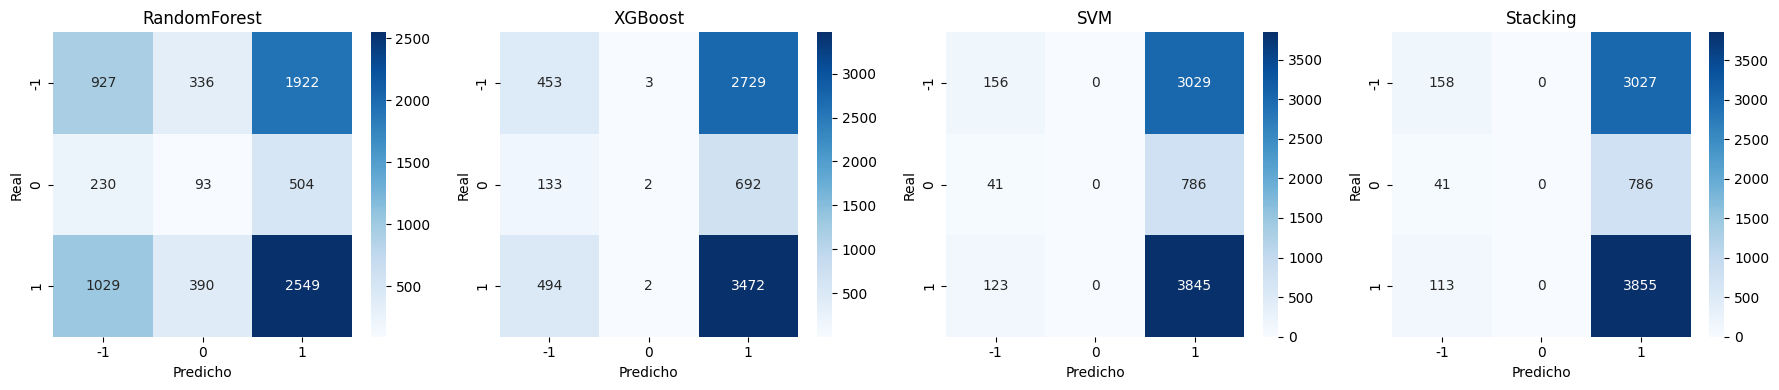

In [60]:
#  Comparativa 
results = {'RandomForest': {'Accuracy': accuracy_score(y_test, y_pred_rf), 'Preds': y_pred_rf},
            'XGBoost':      {'Accuracy': acc_xgb, 'Preds': y_pred_xgb},
            'SVM':          {'Accuracy': acc_svm, 'Preds': y_pred_svm},
            'Stacking':     {'Accuracy': acc_stacking, 'Preds': y_pred_stacking}}

best_model_name = max(results, key = lambda k: results[k]['Accuracy'])
print(f"Mejor modelo: {best_model_name}")
resumen = pd.DataFrame({
    'Modelo': ['RandomForest', 'XGBoost', 'SVM', 'Stacking'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf), acc_xgb, acc_svm, acc_stacking],
    'Tiempo (s)': [grid_rf.refit_time_, time_xgb, time_svm, time_stacking]}).set_index('Modelo').round(4)

display(resumen)

# Matrices de confusión
preds = {'RandomForest': y_pred_rf, 'XGBoost': y_pred_xgb, 'SVM': y_pred_svm, 'Stacking': y_pred_stacking}
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, y_pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', ax=ax,
                xticklabels = sorted(y.unique()), yticklabels = sorted(y.unique()))
    ax.set_title(name)
    ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
plt.tight_layout()
plt.show()

Se comparan cuatro modelos sobre los mismos features y partición train/test de la Pregunta 4:

El **Stacking** alcanza el mayor accuracy (**50.29%**), combinando RF y SVM rbf como modelos base con Regresión Logística como meta-estimador. Sin embargo, la ganancia sobre el SVM es marginal (**0.15 puntos porcentuales**) a un costo computacional **3.7 veces mayor** (1412s vs 380s). El **XGBoost** destaca como la mejor relación accuracy/tiempo, logrando un **49.21%** en apenas **2.98 segundos**, siendo prácticamente equivalente al SVM en rendimiento predictivo.

El problema del desbalance de clases persiste en todos los modelos. De forma notable, SVM y Stacking presentan recall **0.00** para la clase 0 (labor doméstica), ignorándola completamente en sus predicciones y concentrando todos sus aciertos en las clases -1 y 1. El **Random Forest** es el único modelo que intenta predecir la clase minoritaria (recall 0.11), lo que explica su menor accuracy global pero mejor macro avg en recall (**0.35** vs **0.34** de los demás modelos). Este comportamiento refleja que el parámetro `class_weight='balanced'` del RF logra un mejor balance entre clases a costa de reducir la precisión en las clases mayoritarias.

En términos de **velocidad de cómputo**, la diferencia es dramática: XGBoost es **473 veces más rápido** que el Stacking con resultados comparables, lo que lo posiciona como el modelo más eficiente para este problema en términos de la relación rendimiento/costo computacional.

### 6. Utilice alguno de los metodos de clustering vistos en clases para generar grupos en base a las variables IMCE y actividad fisica. Que puede concluir de los resultados?

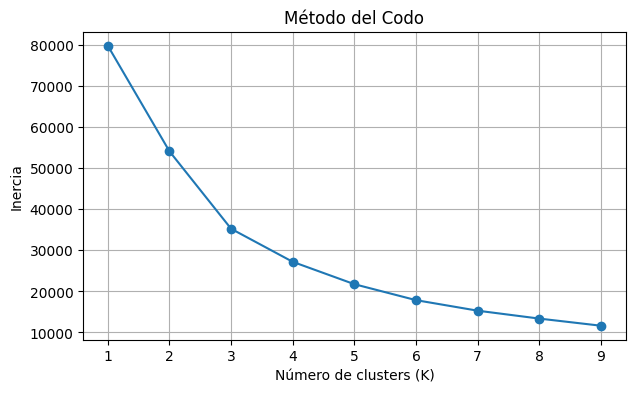

In [47]:
# Codo
X_cluster = StandardScaler().fit_transform(data[['imce', 'act_fisica']])

inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'o-')
plt.title('Método del Codo')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

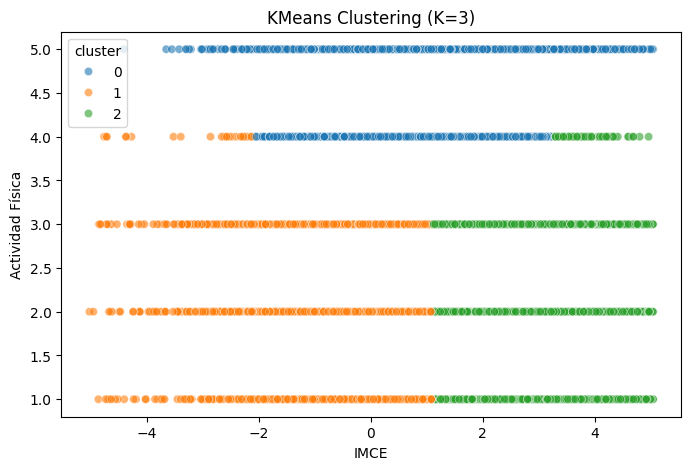

Medias por cluster:


imce        act_fisica       
          mean  count       mean  count
cluster                                
0        0.882   5158      4.624   5158
1        0.005  18616      2.241  18616
2        2.220  16124      2.250  16124

In [48]:
# Kmeans
k_opt = 3

kmeans = KMeans(n_clusters = k_opt, random_state = 42, n_init = 10)
data['cluster'] = kmeans.fit_predict(X_cluster)

plt.figure(figsize=(8, 5))
sns.scatterplot(data = data, x = 'imce', y = 'act_fisica', hue = 'cluster', palette = 'tab10', alpha = 0.6)
plt.title(f'KMeans Clustering (K = {k_opt})')
plt.xlabel('IMCE')
plt.ylabel('Actividad Física')
plt.show()

print("Medias por cluster:")
display(data.groupby('cluster')[['imce', 'act_fisica']].agg(['mean', 'count']).round(3))

Se aplica **KMeans clustering** sobre las variables `imce` y `act_fisica`, escaladas previamente con StandardScaler para igualar sus rangos y evitar que el IMCE, al tener mayor varianza, domine artificialmente la métrica de distancia. El **método del codo** muestra un quiebre en **K=3**, donde la reducción marginal de inercia comienza a aplanarse, por lo que se selecciona ese valor como número óptimo de clusters.

Los clusters se diferencian principalmente por **actividad física** más que por IMCE. El **Cluster 0** agrupa estudiantes con alta actividad física (promedio 4.6 sobre 5) y un IMCE levemente positivo, representando al grupo más activo físicamente pero con un peso corporal cercano a la norma. El **Cluster 1** es el más numeroso con **18,616 observaciones**, y caracteriza a estudiantes con actividad física baja e IMCE neutro, configurando el perfil de estudiante sedentario con peso normal. El **Cluster 2** es el más relevante desde la perspectiva del IMCE, con el valor promedio más alto (**2.22 desviaciones estándar sobre la media**) y una actividad física similar al Cluster 1, lo que sugiere que en este grupo el sobrepeso no está asociado a un menor nivel de actividad física sino posiblemente a factores dietéticos o metabólicos. La naturaleza discreta de `act_fisica` (valores enteros del 1 al 5) genera las líneas horizontales características observadas en el scatterplot, lo cual es esperable dado el tipo de variable.

### 7. Elija el grupo con mayor IMCE promedio en base a la Pregunta 6. Estime nuevamente su mejor modelo de la Pregunta 5. Que puede concluir de sus resultados?

In [63]:
cluster_means = data.groupby('cluster')['imce'].mean()
best_cluster = cluster_means.idxmax()
print(f"Cluster con mayor IMCE promedio: {best_cluster}")
print(cluster_means.round(3))

df_sub = data[data['cluster'] == best_cluster].copy()

X_sub = df_sub[['Cognitivo', 'Emocional', 'Social']]
y_sub = df_sub['madre_work'].astype(str)

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_sub, y_sub, test_size = 0.2, random_state = 42, stratify = y_sub)

le_s = LabelEncoder()
model_q7 = clone(stacking)
model_q7.fit(X_tr_s, le_s.fit_transform(y_tr_s))
y_pred_s = le_s.inverse_transform(model_q7.predict(X_te_s))

print(f"\nAccuracy en submuestra (cluster {best_cluster}): {accuracy_score(y_te_s, y_pred_s):.4f}\n")
print(classification_report(y_te_s, y_pred_s))

Cluster con mayor IMCE promedio: 2
cluster
0    0.882
1    0.005
2    2.220
Name: imce, dtype: float64

Accuracy en submuestra (cluster 2): 0.5113

              precision    recall  f1-score   support

          -1       0.53      0.04      0.07      1245
           0       0.00      0.00      0.00       345
           1       0.51      0.98      0.67      1635

    accuracy                           0.51      3225
   macro avg       0.35      0.34      0.25      3225
weighted avg       0.46      0.51      0.37      3225



Se identifica el **Cluster 2** como el grupo con mayor IMCE promedio (**2.220**), correspondiente a estudiantes con sobrepeso significativo y actividad física baja-media. Este subgrupo contiene **16,124 observaciones**, de las cuales **3,225** conforman el conjunto de test.

Se reentrena el mejor modelo de P5 (**Stacking**) exclusivamente sobre esta submuestra, manteniendo los mismos features (factor scores Cognitivo, Emocional, Social) y la misma partición 80/20 con estratificación.

El **accuracy obtenido es 51.13%**, levemente superior al Stacking entrenado sobre la muestra completa (**50.29%**). Sin embargo, la diferencia es marginal y no indica una mejora sustantiva del poder predictivo. El patrón de predicción es prácticamente idéntico al modelo completo: la clase 0 (labor doméstica) presenta recall **0.00**, siendo ignorada completamente por el modelo, mientras que la clase 1 (empleada) concentra la mayoría de los aciertos con recall **0.98**.

Esto sugiere que dentro del subgrupo de estudiantes con mayor IMCE, la relación entre el desarrollo psicosocial del niño y el estado laboral de la madre no es cualitativamente distinta a la observada en la población general. El desbalance de clases dentro del cluster 2 (1,245 clase -1, 345 clase 0, 1,635 clase 1) replica la distribución desbalanceada de la muestra completa, lo que explica el comportamiento similar del modelo.

###  8 Revise el notebook Sentiment_Analysis.ipynb. Considere la variable *narrative*, limpiar stopwords y tokenizar. Prepare los features necesarios (excluyendo sk1-sk13), y vuelva a estimar su mejor modelo de la Pregunta 5. Compare y discuta sus resultados.

In [62]:
nltk.download('stopwords', quiet = True)

stops = set(stopwords.words('spanish'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-záéíóúñü\s]', ' ', text)
    return ' '.join(w for w in text.split() if w not in stops and len(w) > 2)

data['clean_narrative'] = data['resumen_sk'].apply(clean_text)

vect = TfidfVectorizer(max_features = 200, ngram_range = (1, 2))
X_text = vect.fit_transform(data['clean_narrative']).toarray()
df_text = pd.DataFrame(X_text, columns = [f'tf_{w}' for w in vect.get_feature_names_out()], index = data.index)

# Features sin sk1-sk13
X_nlp = pd.concat([data[['imce', 'act_fisica', 'edad', 'sexo']], df_text], axis = 1)
y_nlp = data['madre_work'].astype(str)

X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    X_nlp, y_nlp, test_size = 0.2, random_state = 42, stratify = y_nlp)

model_q7 = clone(stacking)
model_q7.fit(X_tr_n, y_tr_n)
y_pred_n = model_q7.predict(X_te_n)

print(f"Mejor modelo de P5: {best_model_name}")
print(f"Accuracy con features base + NLP: {accuracy_score(y_te_n, y_pred_n):.4f}\n")
print(classification_report(y_te_n, y_pred_n))

Mejor modelo de P5: Stacking
Accuracy con features base + NLP: 0.5011

              precision    recall  f1-score   support

          -1       0.45      0.14      0.22      3185
           0       0.00      0.00      0.00       827
           1       0.51      0.89      0.65      3968

    accuracy                           0.50      7980
   macro avg       0.32      0.35      0.29      7980
weighted avg       0.43      0.50      0.41      7980



Se implementa un pipeline de Procesamiento de Lenguaje Natural (NLP) sobre la variable `narrative` (denominada `resumen_sk` en el dataset). El texto es preprocesado eliminando stopwords en español, caracteres no alfabéticos y palabras de menos de 3 caracteres. Posteriormente se vectoriza mediante **TF-IDF** con **200 features** y bigramas (`ngram_range=(1,2)`), que a diferencia del CountVectorizer del notebook de referencia, pondera la frecuencia de los términos ajustando por su rareza en el corpus, capturando mejor los términos discriminativos.

Los features del modelo final combinan las variables demográficas base (`imce`, `act_fisica`, `edad`, `sexo`) con las 200 features TF-IDF del texto, excluyendo explícitamente las variables `sk1`-`sk13` según lo indicado en el enunciado. Se reentrena el mejor modelo de P5 (**Stacking**) sobre esta nueva representación.

El **accuracy obtenido es 50.11%**, prácticamente idéntico al Stacking de P5 (**50.29%**) que utilizaba únicamente los 3 factor scores como features. Este resultado no es sorprendente si se considera que la variable `narrative` es un **texto generado automáticamente a partir de las mismas variables `sk1`-`sk13`** (tal como lo indica el diccionario de datos: *"Generated narrative text based on sk1-sk13"*). En consecuencia, el TF-IDF está capturando términos como "siempre", "casi siempre" o "nunca" que son simplemente los valores de las sk codificados en lenguaje natural, sin aportar información genuinamente nueva respecto a los factor scores derivados en P2.

Esto explica por qué agregar **200 features de texto** no mejora la capacidad predictiva: ambos modelos están accediendo esencialmente a la misma señal en representaciones distintas. El desbalance de clases persiste con recall **0.00** para la clase 0, confirmando que es un problema estructural del target independiente de los features utilizados. Para obtener una mejora real con NLP sería necesario contar con texto generado libremente por evaluadores, no con narrativas automatizadas.